In [76]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from LoadStockData import LoadStockData
from TCNDQN_Environment import Environment
from TCNDQN import TCN_DQN
from tqdm import tqdm


class DQNAgent:
    def __init__(self, price_size, cost_size, layer_channels, kernel_size, action_size, device="cpu"):
        self.device = device
        # DQN 模型
        self.policy_net = TCN_DQN(price_size, cost_size, layer_channels, kernel_size, action_size).to(device)
    
    def act(self, price, costs):
        """ 選擇最佳動作 (測試時不使用 epsilon-greedy) """
        with torch.no_grad():  # 測試時不需要計算梯度
            q_values = self.policy_net(price, costs)
            # print(q_values)
        return torch.argmax(q_values).item()  # 選擇預測的最佳動作
    
    
    def test(self, env, test_start_date, test_end_date, model_path, num, trend):
        """ 測試 DQN 模型在給定的環境中運行表現 """
        # 加載訓練好的模型
        self.policy_net.load_state_dict(torch.load(model_path, map_location=self.device, weights_only=True))
        self.policy_net.eval()
        env.reset()

        # 理論上是20210101~20210331，但因為DQN跑出來的action是要給明天執行的，所以要提前一天
        # 變成20201231~20210330
        start_step = env.get_step(test_start_date) - 1 # 20201231
        end_step = env.get_step(test_end_date)        # 20210331，range函數只會取到20210330    
        print(start_step, end_step)

        price = env.get_input_data(start_step).to(self.device)
        # print(f"price shape:{price.shape}")
        # costs = env.load_costs(f"./model/{trend}_trend/{num}") # torch.Size([1, 2, tcn_window])
        costs = env.load_costs(f"./model/16season-{num}/{trend}") # torch.Size([1, 2, tcn_window])
        # print(f"costs:{costs}")

        total_reward = 0.0
        action_list = []

        for step in tqdm(range(start_step, end_step)):
            # 判斷是否結束
            done = step == end_step - 1
            # 使用 DQN 模型選擇動作
            action = self.act(price, costs)
            action_list.append(action) 
            # 動作執行，更新持有數量以及資產狀態
            env.action_execution(action, step) 
            # 計算獎勵
            reward = env.get_reward(step, done ,type = "test")
            total_reward += reward.item()
            # 獲取下一步的狀態
            next_price = env.get_input_data(step + 1) 
            next_costs = env.get_assets_state(step + 1)            
            # 更新狀態
            price = next_price
            costs = next_costs

        return total_reward, action_list
    
    
    
    


In [77]:
trend = "2024-4"  # 上漲、下跌、盤整
num = 3


# 設定路徑
# model_path = f'./model/{trend}_trend/{num}/' 
# strategy_path = f"./strategy/{trend}_trend"
model_path = f"./model/16season-{num}/{trend}/"
strategy_path = f"./strategy/16season/{trend}/"
# 創建資料夾（如果不存在的話）
Path(strategy_path).mkdir(parents=True, exist_ok=True)
# 在程式開始時清空文件內容
with open(f'{strategy_path}/{num}.txt', 'w') as file:
    file.write('')

# 測試超參數
sliding_window = 60
const = 10
cost_names = ["avgcost","Total cost"]
start_date = 20000101  # 設定資料起始日期
end_date = 20250605  # 設定資料結束日期
# if trend == "up":
#     # 上漲
#     test_start_date = 20210101  # 設定測試起始日期
#     test_end_date = 20210331  # 設定測試結束日期
# elif trend == "down":
#     # 下跌
#     test_start_date = 20220401  # 設定測試起始日期
#     test_end_date = 20220630  # 設定測試結束日期
# elif trend == "flat":
#     # 盤整
#     test_start_date = 20241001  # 設定測試起始日期
#     test_end_date = 20241231  # 設定測試結束日期
# elif trend == "all":
#     # 2021-2024
#     test_start_date = 20210101  # 設定測試起始日期
#     test_end_date = 20241231  # 設定測試結束日期
# else:
#     # 2025
#     test_start_date = 20250101  # 設定測試起始日期
#     test_end_date = 20250531  # 設定測試結束日期



# 根據季度設定 train_end_date
if trend == "2021-1":
    test_start_date = 20210101  # 設定測試起始日期
    test_end_date = 20210331  # 設定測試結束日期
elif trend == "2021-2":
    test_start_date = 20210401  # 設定測試起始日期
    test_end_date = 20210630  # 設定測試結束日期
elif trend == "2021-3":
    test_start_date = 20210701  # 設定測試起始日期
    test_end_date = 20210930  # 設定測試結束日期
elif trend == "2021-4":
    test_start_date = 20211001  # 設定測試起始日期
    test_end_date = 20211231  # 設定測試結束日期
elif trend == "2022-1":
    test_start_date = 20220101  # 設定測試起始日期
    test_end_date = 20220331  # 設定測試結束日期
elif trend == "2022-2":
    test_start_date = 20220401  # 設定測試起始日期
    test_end_date = 20220630  # 設定測試結束日期
elif trend == "2022-3":
    test_start_date = 20220701  # 設定測試起始日期
    test_end_date = 20220930  # 設定測試結束日期
elif trend == "2022-4":
    test_start_date = 20221001  # 設定測試起始日期
    test_end_date = 20221231  # 設定測試結束日期
elif trend == "2023-1":
    test_start_date = 20230101  # 設定測試起始日期
    test_end_date = 20230331  # 設定測試結束日期
elif trend == "2023-2":
    test_start_date = 20230401  # 設定測試起始日期
    test_end_date = 20230630  # 設定測試結束日期
elif trend == "2023-3":
    test_start_date = 20230701  # 設定測試起始日期
    test_end_date = 20230930  # 設定測試結束日期
elif trend == "2023-4":
    test_start_date = 20231001  # 設定測試起始日期
    test_end_date = 20231231  # 設定測試結束日期
elif trend == "2024-1":
    test_start_date = 20240101  # 設定測試起始日期
    test_end_date = 20240331  # 設定測試結束日期
elif trend == "2024-2":
    test_start_date = 20240401  # 設定測試起始日期
    test_end_date = 20240630  # 設定測試結束日期
elif trend == "2024-3":
    test_start_date = 20240701  # 設定測試起始日期
    test_end_date = 20240930  # 設定測試結束日期
elif trend == "2024-4":
    test_start_date = 20241001  # 設定測試起始日期
    test_end_date = 20241231  # 設定測試結束日期
else: #2021-2024
    test_start_date = 20210101  # 設定測試起始日期
    test_end_date = 20241231  # 設定測試結束日期



# TCN hyper-parameters
tcn_window = 256  # TCN 的時間窗口大小   
layer_channels = [12, 12, 12, 12, 12, 12, 12]  # 7 層
kernel_size = 3

# 設置設備
device = ("cuda" if torch.cuda.is_available() else "cpu")

    

In [78]:
# 載入數據
aux_market_names = [
    "S&P_500",
    "Dow_Jones",
    "NASDAQ",
    "PHLX",
    "N225",
    "FTSE",
    "FCHI",
    "DAX",
    "000001.SS",
]
filename = "StockData/TWII.csv"
data_period = (start_date - 10000, end_date)
field_names = ["close","change"]
Stock_Data = LoadStockData("TWII", field_names, filename, data_period)
Stock_Data.AddNewData(
    aux_market_names,
    [
        "StockData/S&P_500.csv",
        "StockData/Dow_Jones.csv",
        "StockData/NASDAQ.csv",
        "StockData/PHLX.csv",
        "StockData/N225.csv",
        "StockData/FTSE.csv",
        "StockData/FCHI.csv",
        "StockData/DAX.csv",
        "StockData/000001.SS.csv",
    ],
)

# 獲取所有股市的價格資料
selected_market_names = ["TWII"] + aux_market_names
dates, prices = Stock_Data.get_prices(data_period, field_names, selected_market_names)
if len(field_names) < 2:
    prices = np.squeeze(prices, axis=1)

# 將資料轉換為 torch tensor
prices = torch.FloatTensor(prices)
# print(f"price shape:{prices.shape}")
# exit()


# 初始化環境
env = Environment(prices, dates, start_date=start_date, end_date = end_date,
tcn_window=tcn_window, sliding_window=sliding_window, const = const, device=device)
# 初始化 DQN 測試代理
action_size = 3  # Buy, Sell, Hold
price_size = len(selected_market_names)  # TCN 輸出的股價狀態維度
cost_size = len(cost_names)  # TCN 輸出的成本狀態維度

agent = DQNAgent(price_size, cost_size, layer_channels, kernel_size, action_size, device=device)




> adding stock market: S&P_500 
> adding stock market: Dow_Jones 
> adding stock market: NASDAQ 
> adding stock market: PHLX 
> adding stock market: N225 
> adding stock market: FTSE 
> adding stock market: FCHI 
> adding stock market: DAX 
> adding stock market: 000001.SS 


In [79]:
import re

folder_path = Path(model_path)
# 統計符合 modelX.pt 格式的 .pt 檔案數量
txt_file_count = len([file for file in folder_path.glob("*.pt") if re.match(r"model\d+\.pt", file.name)])
print(f"資料夾 {folder_path} 中的符合 modelX.pt 格式的 .pt 檔案數量為：{txt_file_count}")

model_reward = []
action_list = []


for idx in range(1,txt_file_count+1):
    total_reward, action_list = agent.test(env, test_start_date, test_end_date, model_path + f"model{idx}.pt", num, trend)
    print(f"model{idx}, Total Reward: {total_reward}")
    model_reward.append(total_reward)
    # 使用 write() 方法寫入
    with open(f'{strategy_path}/{num}.txt', 'a') as file:
        file.write(f'{idx - 1} : {action_list}\n')
    # print(f"action:{action_list}")

print(f"Highest reward: {max(model_reward)}, No. of model: {model_reward.index(max(model_reward)) + 1}")   
print(f"Lowest reward: {min(model_reward)}, No. of model: {model_reward.index(min(model_reward)) + 1}")
print(f"Average reward: {sum(model_reward) / len(model_reward)}")

資料夾 model\16season-3\2024-4 中的符合 modelX.pt 格式的 .pt 檔案數量為：100
6313 6375


100%|██████████| 62/62 [00:00<00:00, 148.65it/s]


model1, Total Reward: 0.0
6313 6375


100%|██████████| 62/62 [00:00<00:00, 285.65it/s]


model2, Total Reward: 3301.984375
6313 6375


...

model98, Total Reward: 7901.26171875
6313 6375


100%|██████████| 62/62 [00:00<00:00, 289.65it/s]


model99, Total Reward: 3507.861328125
6313 6375


100%|██████████| 62/62 [00:00<00:00, 286.97it/s]

model100, Total Reward: 3405.375
Highest reward: 7901.26171875, No. of model: 98
Lowest reward: -10685.359375, No. of model: 75
Average reward: 1400.04083984375


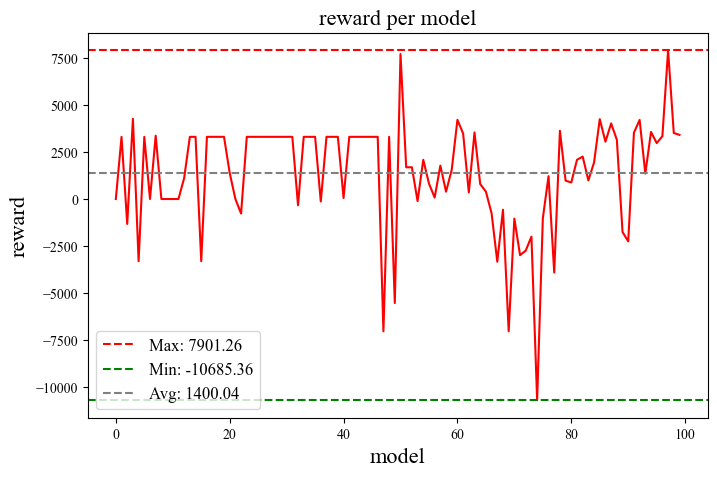

In [80]:
x = [reward for reward in model_reward]
plt.rcParams["font.family"] = "Times New Roman" # 設置字體為 Times New Roman
plt.figure(figsize=(8, 5))
plt.plot(x, "-r")

# 計算最高點、最低點和平均值
max_reward = max(model_reward)
min_reward = min(model_reward)
avg_reward = sum(model_reward) / len(model_reward)

# 添加虛線標示
plt.axhline(y=max_reward, color="red", linestyle="--", label=f"Max: {max_reward:.2f}")
plt.axhline(y=min_reward, color="green", linestyle="--", label=f"Min: {min_reward:.2f}")
plt.axhline(y=avg_reward, color="gray", linestyle="--", label=f"Avg: {avg_reward:.2f}")


# 添加圖例
plt.legend(fontsize=12, loc="best")  # loc="best" 自動選擇最佳位置顯示圖例
plt.xlabel("model", fontsize=16)
plt.ylabel("reward", fontsize=16)
plt.title("reward per model", fontsize=16)
pic_path = f'./picture/test/{trend}_trend'
Path(pic_path).mkdir(parents=True, exist_ok=True)  # 如果資料夾不存在則創建
plt.savefig(f'{pic_path}/{num}.png')
plt.show()